# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [21]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import matplotlib.ticker as ticker # Custom formatter: Format y-axis labels as Millions/Thousands
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score,
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold,
    validation_curve
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# ============================================
# Custom Formatter Functions
# ============================================

# Format numbers in thousands (e.g., 10,000 → 10K)
def thousands_formatter(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.0f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

# Format dollars in millions/thousands
def dollars_formatter(x, pos):
    if x >= 1e6:
        return f'${x/1e6:.1f}M'
    elif x >= 1e3:
        return f'${x/1e3:.0f}K'
    else:
        return f'${x:.0f}'

# Register the formatters
thousands_fmt = ticker.FuncFormatter(thousands_formatter)
dollars_fmt = ticker.FuncFormatter(dollars_formatter)


## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [7]:
# ==============================================================================
# MILESTONE 2: Load Preprocessed Dataset from Milestone 1 Project. New datasets
# ==============================================================================
base_url = "https://github.com/dn603/Module-3-Milestone-2/raw/refs/heads/main/"

# List of files to download
files = [
    "X_train_clean.csv.zip",
    "X_test_clean.csv.zip",
    "y_train_clean.csv.zip",
    "y_test_clean.csv.zip"
]

downloaded_data = {}

for file in files:
    url = base_url + file
    filename = os.path.basename(urlparse(url).path)
    
    if not os.path.exists(filename):
        try:
            print(f"Downloading {file}...")
            response = requests.get(url)
            response.raise_for_status()
            with open(filename, "wb") as f:
                f.write(response.content)
            print(f"   {file} downloaded successfully.")
        except requests.exceptions.RequestException as e:
            print(f"   Error downloading {file}: {e}")
    else:
        print(f"   {file} already exists. Skipping download.")

# Load the files
X_train = pd.read_csv("X_train_clean.csv.zip")
X_test = pd.read_csv("X_test_clean.csv.zip")
y_train = pd.read_csv("y_train_clean.csv.zip").squeeze("columns")
y_test = pd.read_csv("y_test_clean.csv.zip").squeeze("columns")

   X_train_clean.csv.zip already exists. Skipping download.
   X_test_clean.csv.zip already exists. Skipping download.
   y_train_clean.csv.zip already exists. Skipping download.
   y_test_clean.csv.zip already exists. Skipping download.


In [3]:
# ============================================
# MILESTONE 2: DATASET SUMMARY
# ============================================

print("=" * 60)
print("MILESTONE 2: DATASET SUMMARY")
print("=" * 60)

print(f"\nTraining Set:")
print(f"   X_train: {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features")
print(f"   y_train: {y_train.shape[0]:,} samples")

print(f"\nTest Set:")
print(f"   X_test: {X_test.shape[0]:,} samples, {X_test.shape[1]:,} features")
print(f"   y_test: {y_test.shape[0]:,} samples")

# Combine train and test to show full dataset stats
total_rows = X_train.shape[0] + X_test.shape[0]
total_features = X_train.shape[1]  # Should be same as X_test

print(f"\nFull Dataset (Combined):")
print(f"   Total rows:    {total_rows:,}")
print(f"   Total columns: {total_features:,}")

# Check for missing values
print(f"\nData Quality:")
print(f"   Missing values in X_train: {X_train.isnull().sum().sum():,}")
print(f"   Missing values in X_test:  {X_test.isnull().sum().sum():,}")

# Target variable statistics (using y_train + y_test)
y_full = pd.concat([y_train, y_test])
print(f"\nTarget (taxvaluedollarcnt):")
print(f"   Mean:  ${y_full.mean():,.2f}")
print(f"   Median: ${y_full.median():,.2f}")
print(f"   Min:   ${y_full.min():,.2f}")
print(f"   Max:   ${y_full.max():,.2f}")

# Column types
print(f"\nColumn Types:")
print(f"   Numeric columns: {X_train.select_dtypes(include=['number']).shape[1]:,}")
print(f"   Object columns:  {X_train.select_dtypes(include=['object']).shape[1]:,}")


print("\nNEW DATASETS ARE CLEAN AND READY!")

MILESTONE 2: DATASET SUMMARY

Training Set:
   X_train: 62,057 samples, 2,928 features
   y_train: 62,057 samples

Test Set:
   X_test: 15,515 samples, 2,928 features
   y_test: 15,515 samples

Full Dataset (Combined):
   Total rows:    77,572
   Total columns: 2,928

Data Quality:
   Missing values in X_train: 0
   Missing values in X_test:  0

Target (taxvaluedollarcnt):
   Mean:  $490,072.32
   Median: $358,878.50
   Min:   $1,000.00
   Max:   $49,061,236.00

Column Types:
   Numeric columns: 2,928
   Object columns:  0

NEW DATASETS ARE CLEAN AND READY!


## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

In [4]:
# ============================================
# PART 1: Model Selection and Baselines
# ============================================

# We agreed on using the following models for our baseline comparisons:
# Linear Regression, Random Forest, and Decision Tree.

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

# Repeated CV setup and check for overfitting
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

results = []

for name, model in models.items():
    print(f"\n{name}:")
    print("~" * 30)

    # Fit on full training set
    model.fit(X_train, y_train)
    
    # Predict on training set
    y_train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation scores (negative MAE)
    neg_mae_scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=repeated_cv,
        n_jobs=3
    )
    
    # Convert to positive MAE
    mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(mae_scores)
    std_cv_mae = np.std(mae_scores)

    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")
    
    # Store results
    results.append({
        'Model Name': name,
        'Train MAE': train_mae,
        'Mean CV MAE': mean_cv_mae,
        'Std CV MAE': std_cv_mae,
    })

# Find best model
results_df = pd.DataFrame(results)
best_idx = np.argmin(results_df['Mean CV MAE'])
print("\n" + "=" * 30)
print(f"BEST MODEL: {results_df.iloc[best_idx]['Model Name']}")
print(f"   Mean CV MAE: ${results_df.iloc[best_idx]['Mean CV MAE']:,.2f}")
print(f"   Std CV MAE:  ${results_df.iloc[best_idx]['Std CV MAE']:,.2f}")


Linear Regression:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $208,812.92
   Mean CV MAE:  $222,082.91
   Std CV MAE:   $3,221.06

Random Forest:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $70,974.10
   Mean CV MAE:  $190,151.83
   Std CV MAE:   $3,345.72

Decision Tree:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,598.07
   Mean CV MAE:  $248,261.79
   Std CV MAE:   $3,922.31

BEST MODEL: Random Forest
   Mean CV MAE: $190,151.83
   Std CV MAE:  $3,345.72


### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score **?

- The **Random Forest** model has the **lowest** validation MAE with **$190,151.83**

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

- The **Linear Regression** model has the **smallest** standard deviation **$3,221.06**
- **Linear Regression** is the most stable across different data splits
- **Random Forest** is nearly as stable with better predictive performance. 
- **Decision Tree** shows the most variability and less reliable generalization

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

- The **Decistion Tree** Training MAE has: 2,598 - 248,262 = **-\$245,664** gap, which indicates **overfitting** 
    - The **Training MAE** is very **low**, which means it almost memorizes the data
    - The **CV MAE** has the **highest** value out of the three models. This indicates it fails to generalize
- The **Linear Regression** model appears to be underfit. 
    - This model has the **highest Training MAE** score of **\$208,812.92** out of the 3 models
    - The gap between the **Training MAE** and **The CV MAE** is only **\$13,270**

#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

- **Linear Regression**: Simple, stable, but has low accuracy
- **Random Forest**: Best accuracy, stable performance (low  **Std CV MAE: $3,346**), but overfit the training data
- **Decision Tree**: The most overfitting model (Training MAE is very low, while CV MAE is the highest)

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats). 
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

In [16]:
# ================================================
# PART 2: Evaluate Feature Engineering Hypotheses
# ================================================

# BASELINE RESULTS (from Part 1)
baseline_results = {
    'Linear Regression': {
        'Mean CV MAE': 222082.91,
        'Std CV MAE': 3221.06,
        'Train MAE': 208812.92
    },
    'Random Forest': {
        'Mean CV MAE': 190151.83,
        'Std CV MAE': 3345.72,
        'Train MAE': 70974.10
    },
    'Decision Tree': {
        'Mean CV MAE': 248261.79,
        'Std CV MAE': 3922.31,
        'Train MAE': 2598.07
    }
}
baseline_df = pd.DataFrame(baseline_results).T

# From your Milestone 1 analysis, here are our feature engineering ideas:
#   1. Log Transform of Target
#   2. Remove Highly Correlated Features
#   3. Interaction Features

In [17]:
# ------------------------------------------
# 2.A.1: Log Transform of Target (Dollar CV)
# ------------------------------------------

# Because of the Log scale returns log units, we'll use a custom scorer function
# to convert log units to dollard scale

# Custom scorer: Calculate MAE on original dollar scale
def mae_original_scale(y_true_log, y_pred_log):
    """Calculate MAE on original dollar scale after inverse transform."""
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_orig, y_pred_orig)

# Create scorer for cross-validation
mae_original_scorer = make_scorer(mae_original_scale, greater_is_better=False)

# Create log-transformed target
y_train_log = np.log1p(y_train)

# Store results
results_log = []

print("\n" + "-" * 50)
print("2.A.1: Log Transform of Target (Dollar CV)")
print("-" * 50)

for name, model in models.items():
    print(f"\n{name}")
    print("~" * 30)
    
    # Fit on log-transformed target
    model.fit(X_train, y_train_log)
    
    # Predict on training set (original dollar scale)
    y_train_pred_log = model.predict(X_train)
    y_train_pred = np.expm1(y_train_pred_log)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation
    neg_mae_scores = cross_val_score(
        model, X_train, y_train_log,
        
        # Returns MAE in dollars
        scoring=mae_original_scorer,
        cv=repeated_cv,
        n_jobs=3
    )

    # Convert to positive MAE
    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)
    
    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")

    # Compare to baseline (Part 1)
    baseline_mean = baseline_results[name]['Mean CV MAE']
    improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100
    
    print(f"   Improvement:  {improvement_pct:+.2f}% vs baseline")
    
    # Store results
    results_log.append({
        'Model Name': name,
        'Train MAE ($)': f"${train_mae:,.2f}",
        'Mean CV MAE ($)': f"${mean_cv_mae:,.2f}",
        'Std CV MAE ($)': f"${std_cv_mae:,.2f}",
        'Baseline CV MAE ($)': f"${baseline_mean:,.2f}",
        'Improvement': f"{improvement_pct:+.2f}%"
    })

# Find best model for this idea
best_idx = np.argmin([float(r['Mean CV MAE ($)'].replace('$', '').replace(',', '')) for r in results_log])
print("\n" + "=" * 30)
print(f"BEST MODEL with Log Transform: {results_log[best_idx]['Model Name']}")
print(f"   Mean CV MAE: {results_log[best_idx]['Mean CV MAE ($)']}")
print(f"   Std CV MAE:  {results_log[best_idx]['Std CV MAE ($)']}")


--------------------------------------------------
2.A.1: Log Transform of Target (Dollar CV)
--------------------------------------------------

Linear Regression
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $200,619.39
   Mean CV MAE:  $793,473.21
   Std CV MAE:   $2,829,359.08
   Improvement:  -257.29% vs baseline

Random Forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $79,055.44
   Mean CV MAE:  $196,141.44
   Std CV MAE:   $3,529.14
   Improvement:  -3.15% vs baseline

Decision Tree
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,620.01
   Mean CV MAE:  $249,667.90
   Std CV MAE:   $3,905.62
   Improvement:  -0.57% vs baseline

BEST MODEL with Log Transform: Random Forest
   Mean CV MAE: $196,141.44
   Std CV MAE:  $3,529.14


In [18]:
# ------------------------------------------
# 2.A.2: Remove Highly Correlated Features
# ------------------------------------------

print("\n" + "-" * 50)
print("2.A.2: Remove Highly Correlated Features")
print("-" * 50)

# Drop highly correlated features (keeping one from each pair)

# Based on correlation matrix from Module 1:
# - age (correlated with yearbuilt): keep yearbuilt
# - calculatedbathnbr (correlated with fullbathcnt): keep fullbathcnt
# - bathroomcnt (correlated with calculatedbathnbr, fullbathcnt); keep fullbathcnt
# - calculatedfinishedsquarefeet (correlated with finishedsquarefeet12): keep calculatedfinishedsquarefeet
# - garagecarcnt (correlated with has_garage): keep has_garage (also correlated with regionidcounty)
# - has_garage (correlated with regionidcounty): keep regionidcounty (Location more important)
# - garagecarcnt (correlated with garagetotalsqft): keep garagetotalsqft
# - calculatedbathnbr (correlated with calculatedfinishedsquarefeet); keep calculatedfinishedsquarefeet

# Based on correlation matrix from Module 1:
columns_to_drop = [
    'age',                    # correlated with yearbuilt (1.00)
    'calculatedbathnbr',      # correlated with fullbathcnt (0.9848)
    'bathroomcnt',            # correlated with fullbathcnt (0.9686)
    'finishedsquarefeet12',   # correlated with calculatedfinishedsquarefeet (0.9468)
    'has_garage'              # correlated with garagecarcnt (0.9368) and regionidcounty (0.9219)
]

# Drop columns
X_train_drop = X_train.drop(columns=columns_to_drop)

# Store results
results_reduced = []

for name, model in models.items():
    print(f"\n{name}")
    print("~" * 30)
    
    # Fit on reduced feature set
    model.fit(X_train_drop, y_train)
    
    # Predict on training set
    y_train_pred = model.predict(X_train_drop)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation
    neg_mae_scores = cross_val_score(
        model, X_train_drop, y_train,
        scoring='neg_mean_absolute_error',
        cv=repeated_cv,
        n_jobs=3
    )
    
    # Convert to positive MAE
    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)
    
    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")
    
    # Compare to baseline (Part 1)
    baseline_mean = baseline_results[name]['Mean CV MAE']
    improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100
    
    print(f"   Improvement:  {improvement_pct:+.2f}% vs baseline")
    
    # Store results
    results_reduced.append({
        'Model Name': name,
        'Train MAE ($)': f"${train_mae:,.2f}",
        'Mean CV MAE ($)': f"${mean_cv_mae:,.2f}",
        'Std CV MAE ($)': f"${std_cv_mae:,.2f}",
        'Baseline CV MAE ($)': f"${baseline_mean:,.2f}",
        'Improvement': f"{improvement_pct:+.2f}%"
    })

# Find best model for this idea
best_idx = np.argmin([float(r['Mean CV MAE ($)'].replace('$', '').replace(',', '')) for r in results_reduced])
print("\n" + "=" * 30)
print(f"BEST MODEL with Reduced Features: {results_reduced[best_idx]['Model Name']}")
print(f"   Mean CV MAE: {results_reduced[best_idx]['Mean CV MAE ($)']}")
print(f"   Std CV MAE:  {results_reduced[best_idx]['Std CV MAE ($)']}")


--------------------------------------------------
2.A.2: Remove Highly Correlated Features
--------------------------------------------------

Linear Regression
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $208,337.26
   Mean CV MAE:  $221,643.25
   Std CV MAE:   $3,344.85
   Improvement:  +0.20% vs baseline

Random Forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $71,085.27
   Mean CV MAE:  $190,263.80
   Std CV MAE:   $3,334.58
   Improvement:  -0.06% vs baseline

Decision Tree
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,598.07
   Mean CV MAE:  $248,242.60
   Std CV MAE:   $5,020.17
   Improvement:  +0.01% vs baseline

BEST MODEL with Reduced Features: Random Forest
   Mean CV MAE: $190,263.80
   Std CV MAE:  $3,334.58


In [19]:
# ------------------------------------------
# 2.A.3: Create Interaction Features
# ------------------------------------------

print("\n" + "-" * 50)
print("2.A.3: Create Interaction Features")
print("-" * 50)

# Create interaction features based on Milestone 1 analysis:
# - bedroomcnt × bathroomcnt: captures the relationship between bedroom and bathroom counts
# - calculatedfinishedsquarefeet × bathroomcnt: larger homes with more bathrooms should have higher value
# - calculatedfinishedsquarefeet × buildingqualitytypeid: larger homes with higher quality should have higher value

X_train_interact = X_train.copy()

# Interaction features
X_train_interact['bed_bath'] = X_train['bedroomcnt'] * X_train['bathroomcnt']
X_train_interact['sqft_bath'] = X_train['calculatedfinishedsquarefeet'] * X_train['bathroomcnt']
X_train_interact['sqft_quality'] = X_train['calculatedfinishedsquarefeet'] * X_train['buildingqualitytypeid']

# Ratio feature (bathrooms per bedroom)
X_train_interact['bath_per_bed'] = X_train['bathroomcnt'] / (X_train['bedroomcnt'] + 1)

print(f"   Original features: {X_train.shape[1]}")
print(f"   New features:      4 (bed_bath, sqft_bath, sqft_quality, bath_per_bed)")
print(f"   Total features:    {X_train_interact.shape[1]}")

# Store results
results_interact = []

for name, model in models.items():
    print(f"\n{name}")
    print("~" * 30)
    
    # Fit on interaction features
    model.fit(X_train_interact, y_train)
    
    # Predict on training set
    y_train_pred = model.predict(X_train_interact)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation
    neg_mae_scores = cross_val_score(
        model, X_train_interact, y_train,
        scoring='neg_mean_absolute_error',
        cv=repeated_cv,
        n_jobs=3
    )
    
    # Convert to positive MAE
    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)
    
    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")
    
    # Compare to baseline (Part 1)
    baseline_mean = baseline_results[name]['Mean CV MAE']
    improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100
    
    print(f"   Improvement:  {improvement_pct:+.2f}% vs baseline")
    
    # Store results
    results_interact.append({
        'Model Name': name,
        'Train MAE ($)': f"${train_mae:,.2f}",
        'Mean CV MAE ($)': f"${mean_cv_mae:,.2f}",
        'Std CV MAE ($)': f"${std_cv_mae:,.2f}",
        'Baseline CV MAE ($)': f"${baseline_mean:,.2f}",
        'Improvement': f"{improvement_pct:+.2f}%"
    })

# Find best model for this idea
best_idx = np.argmin([float(r['Mean CV MAE ($)'].replace('$', '').replace(',', '')) for r in results_interact])
print("\n" + "=" * 30)
print(f"BEST MODEL with Interaction Features: {results_interact[best_idx]['Model Name']}")
print(f"   Mean CV MAE: {results_interact[best_idx]['Mean CV MAE ($)']}")
print(f"   Std CV MAE:  {results_interact[best_idx]['Std CV MAE ($)']}")


--------------------------------------------------
2.A.3: Create Interaction Features
--------------------------------------------------
   Original features: 2928
   New features:      4 (bed_bath, sqft_bath, sqft_quality, bath_per_bed)
   Total features:    2932

Linear Regression
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $198,170.82
   Mean CV MAE:  $211,234.09
   Std CV MAE:   $3,384.59
   Improvement:  +4.89% vs baseline

Random Forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $71,047.36
   Mean CV MAE:  $190,389.23
   Std CV MAE:   $3,222.59
   Improvement:  -0.12% vs baseline

Decision Tree
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,598.07
   Mean CV MAE:  $249,829.90
   Std CV MAE:   $4,870.58
   Improvement:  -0.63% vs baseline

BEST MODEL with Interaction Features: Random Forest
   Mean CV MAE: $190,389.23
   Std CV MAE:  $3,222.59



FINAL COMPARISON: ALL MODELS ACROSS ALL FEATURE ENGINEERING IDEAS

MODEL CLASS          IDEA                   Train MAE       CV MAE          STD DEV        
-------------------------------------------------------------------------------------
Linear Regression    Baseline               $208,812.92     $222,082.91     $3,221.06      
Random Forest        Baseline               $70,974.10      $190,151.83     $3,345.72      
Decision Tree        Baseline               $2,598.07       $248,261.79     $3,922.31      
Linear Regression    Log Target             $200,619.39     $793,473.21     $2,829,359.08  
Random Forest        Log Target             $79,055.44      $196,141.44     $3,529.14      
Decision Tree        Log Target             $2,620.01       $249,667.90     $3,905.62      
Linear Regression    Remove Correlated      $208,337.26     $221,643.25     $3,344.85      
Random Forest        Remove Correlated      $71,085.27      $190,263.80     $3,334.58      
Decision Tree     

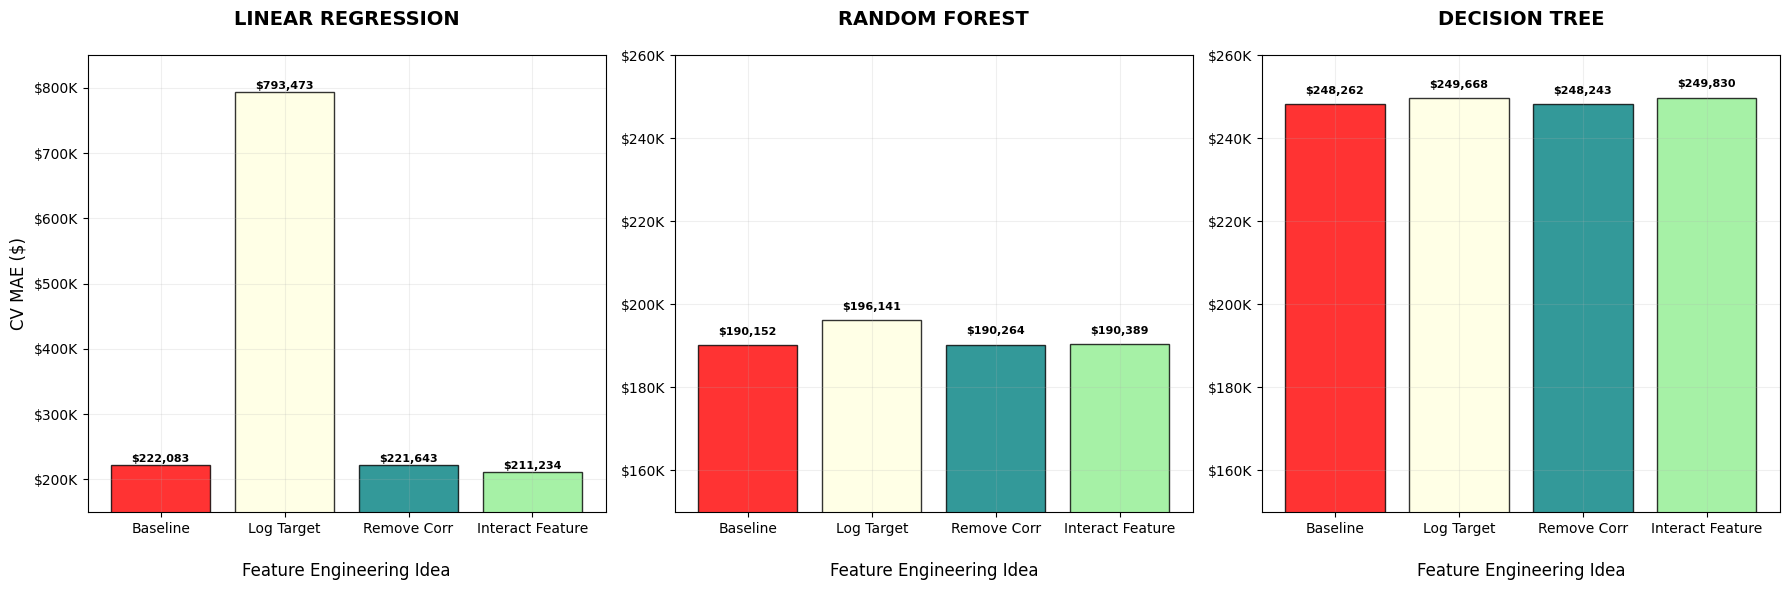

In [12]:
# =============================================================
# PART 2: FINAL COMPARISON - ALL MODELS ACROSS ALL IDEAS
# =============================================================

print("\n" + "=" * 85)
print("FINAL COMPARISON: ALL MODELS ACROSS ALL FEATURE ENGINEERING IDEAS")
print("=" * 85)

# Create data structures for comparison
ideas_list = ['Baseline', 'Log Target', 'Remove Correlated', 'Interaction Features']
models_list = ['Linear Regression', 'Random Forest', 'Decision Tree']

# Results data (Hardcode from outputs)
results_data = {
    'Baseline': {
        'Linear Regression': {'cv_mae': 222082.91, 'std': 3221.06, 'train_mae': 208812.92},
        'Random Forest': {'cv_mae': 190151.83, 'std': 3345.72, 'train_mae': 70974.10},
        'Decision Tree': {'cv_mae': 248261.79, 'std': 3922.31, 'train_mae': 2598.07}
    },
    'Log Target': {
        'Linear Regression': {'cv_mae': 793473.21, 'std': 2829359.08, 'train_mae': 200619.39},
        'Random Forest': {'cv_mae': 196141.44, 'std': 3529.14, 'train_mae': 79055.44},
        'Decision Tree': {'cv_mae': 249667.90, 'std': 3905.62, 'train_mae': 2620.01}
    },
    'Remove Correlated': {
        'Linear Regression': {'cv_mae': 221643.25, 'std': 3344.85, 'train_mae': 208337.26},
        'Random Forest': {'cv_mae': 190263.80, 'std': 3334.58, 'train_mae': 71085.27},
        'Decision Tree': {'cv_mae': 248242.60, 'std': 5020.17, 'train_mae': 2598.07}
    },
    'Interaction Features': {
        'Linear Regression': {'cv_mae': 211234.09, 'std': 3384.59, 'train_mae': 198170.82},
        'Random Forest': {'cv_mae': 190389.23, 'std': 3222.59, 'train_mae': 71047.36},
        'Decision Tree': {'cv_mae': 249829.90, 'std': 4870.58, 'train_mae': 2598.07}
    }
}

# Print comparison table
print(f"\n{'MODEL CLASS':<20} {'IDEA':<22} {'Train MAE':<15} {'CV MAE':<15} {'STD DEV':<15}")
print("-" * 85)

for idea in ideas_list:
    for model in models_list:
        data = results_data[idea][model]
        print(f"{model:<20} {idea:<22} ${data['train_mae']:<14,.2f} ${data['cv_mae']:<14,.2f} ${data['std']:<14,.2f}")

# =============================================================
# BEST PERFORMANCE PER IDEA
# =============================================================

print("\n" + "=" * 85)
print("BEST MODEL PER FEATURE ENGINEERING IDEA (Lowest CV MAE)")
print("=" * 85)

print(f"\n{'BEST MODEL':<20} {'IDEA':<22} {'CV MAE':<15} {'STD':<15}")
print("-" * 85)

for idea in ideas_list:
    best_model = None
    best_mae = float('inf')
    best_std = 0
    
    for model in models_list:
        mae = results_data[idea][model]['cv_mae']
        if mae < best_mae:
            best_mae = mae
            best_model = model
            best_std = results_data[idea][model]['std']
    
    print(f"{best_model:<20} {idea:<22} ${best_mae:<14,.2f} ${best_std:<14,.2f}")

# =============================================================
# BEST IMPROVEMENT BY MODEL
# =============================================================

print("\n" + "=" * 85)
print("BEST IMPROVEMENT PER MODEL (vs Baseline)")
print("=" * 85)

print(f"\n{'MODEL CLASS':<20} {'BEST IDEA':<22} {'CV MAE':<15} {'IMPROVEMENT':<15}")
print("-" * 85)

for model in models_list:
    best_idea = None
    best_mae = float('inf')
    baseline_mae = results_data['Baseline'][model]['cv_mae']
    
    for idea in ideas_list:
        if idea == 'Baseline':
            continue
        mae = results_data[idea][model]['cv_mae']
        if mae < best_mae:
            best_mae = mae
            best_idea = idea
    
    improvement = ((baseline_mae - best_mae) / baseline_mae) * 100
    print(f"{model:<20} {best_idea:<22} ${best_mae:<14,.2f} {improvement:<+5.2f}%")
print("\n")

# =============================================================
# BAR CHARTS (Visualize the result)
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['red', 'lightyellow', 'teal', 'lightgreen']
labels = ['Baseline', 'Log Target', 'Remove Corr', 'Interact Feature']
model_names = ['LINEAR REGRESSION', 'RANDOM FOREST', 'DECISION TREE']

for idx, (ax, title) in enumerate(zip([axes[0], axes[1], axes[2]], model_names)):
    model = models_list[idx]
    values = [results_data[idea][model]['cv_mae'] for idea in ideas_list]
    
    bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_xlabel('\nFeature Engineering Idea', fontsize=12)
    
    if idx == 0:
        ax.set_ylabel('CV MAE ($)', fontsize=12)
    
    ax.set_title(title + '\n', fontsize=14, fontweight='bold')

    # Different y-axis limits for each model
    if idx == 0:  # Linear Regression
        ax.set_ylim(150000, 850000)
    else:  # Random Forest and Decision Tree
        ax.set_ylim(150000, 260000)

    ax.grid(True, alpha=0.2)
    
    # Apply dollar formatter to y-axis
    ax.yaxis.set_major_formatter(dollars_fmt)
    
    # Add value on top of bars (formatted as dollars)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

- **Interaction Features** produced the largest improvement. For Linear Regression, CV MAE improved from **\$222,082.91 to \$211,234.09 (+4.89% improvement)**

- **Log Transform of Target** was terrible for Linear Regression, increasing CV MAE from **\$222,082.91 to \$793,473.21 (-257.29%)**

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

- Yes! Several of our feature engineering ideas were unsuccessful or reduced model performance.

- **Log Transform of Target** was **unsuccessful** for **all three models**, with broken results for Linear Regression. **Random Forest** and **Decision Tree** were more robust, but they still showed slight degradation.

    | Model | Baseline CV MAE | Log Transform CV MAE | Change |
    |-------|----------------|---------------------|--------|
    | Linear Regression | \$222,082.91 | **\$793,473.21** | **-257.29%**|
    | Random Forest | \$190,151.83 | **\$196,141.44** | -3.15% |
    | Decision Tree | \$248,261.79 | **\$249,667.90** | -0.57% |
<br>

- The idea to **Remove Highly Correlated Features** didn't have much impact on all models. Removing these features did not help or hurt performance

    | Model | Baseline CV MAE | Reduced CV MAE | Change |
    |-------|----------------|----------------|--------|
    | Linear Regression | \$222,082.91 | \$221,643.25 | **+0.20%** |
    | Random Forest | \$190,151.83 | \$190,263.80 | **-0.06%** |
    | Decision Tree | \$248,261.79 | \$248,242.60 | **+0.01%** |


#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

- Interaction Features improved Linear Regression by **+4.89%** (from \$222,082.91 to \$211,234.09)
- There's not much of improvement for Ramdom Forest **(-0.12%)** or Decision Tree **(-0.63%)** models

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

- Data shows the **Random Forest model** achieved the best CV MAE **(\$190,151.83)** using the original features set.
- All three of our ideas don't seem to help much
    - Little bit worse with Interactive Features **(-0.12%)**, and Remove high correlated features **(-0.06%)**
    - Log transform **(-3.15)** got worse
- We will drop all three of our ideas. **Keep the same cleaned datasets** for the remainder our the Milestone

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

#### Feature Selection

For the Zillow dataset, a good approach is to use different feature selection methods depending on the model. `Random Forest` has worked well for this dataset so we will use that for this feature selection exercise.

Summary of Selection Methods:

| Model	| Feature Selection Method	| Why |
| :--- | :--- | :--- |
| Linear Regression	| Forward Sequential Feature Selection	| Removes redundant predictors and improves interpretability. |
| Decision Tree	| Feature Importance	| Trees naturally rank features by importance. |
| Random Forest (or HistGradientBoosting)	| Feature Importance	| Ensemble methods provide stable feature importance estimates. |

In [ ]:
# =============================================================
# PART 3: Refine the Feature Set through Feature Selection
# =============================================================

print("\n" + "=" * 90)
print("PART 3: FEATURE SELECTION")
print("=" * 90)

# We'll reuse the best feature-engineering setups from Part 2:
# - Linear Regression: interaction feature dataset (X_train_interact)
# - Random Forest: baseline full feature set (X_train)
# - Decision Tree: reduced correlated feature set (X_train_drop)

part3_results = []


PART 3: FEATURE SELECTION


In [ ]:
# =============================================================
# 3.A.1 Linear Regression + SelectKBest on Interaction Features
# =============================================================

print("\n" + "=" * 50)
print("3.A.1: Linear Regression + Feature Selection")
print("=" * 50)

# Start from the best linear setup from Part 2: interaction features
X_train_lr_fs = X_train_interact.copy()

# Select the strongest predictors using univariate F-tests
k_lr = 120  # 120 features as reasonable number of top features
lr_selector = SelectKBest(score_func=f_regression, k=k_lr)
X_train_lr_selected = lr_selector.fit_transform(X_train_lr_fs, y_train)
selected_lr_features = X_train_lr_fs.columns[lr_selector.get_support()].tolist()

# Retrain Linear Regression on selected features
lr_model_fs = LinearRegression()
lr_model_fs.fit(X_train_lr_selected, y_train)
y_train_pred = lr_model_fs.predict(X_train_lr_selected)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Repeated CV with the same setup as before
neg_mae_scores = cross_val_score(
    lr_model_fs,
    X_train_lr_selected,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)

#convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

# Compare with  Part 2 best Linear Regression CV MAE (~211,234.09)
baseline_mean = 211234.09
improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100

print(f" Original features: {X_train_lr_fs.shape[1]}")
print(f" Selected features: {len(selected_lr_features)}")
print(f" Training MAE: ${train_mae:,.2f}")
print(f" Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f" Std CV MAE: ${std_cv_mae:,.2f}")
print(f" Improvement vs Part 2 best Linear Regression: {improvement_pct:+.2f}%")
print("\nTop selected features for Linear Regression:")
print(selected_lr_features[:20])

part3_results.append({
    "Model Name": "Linear Regression",
    "Feature Set Used": "Interaction Features + SelectKBest",
    "Selected Feature Count": len(selected_lr_features),
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae,
    "Improvement vs Part 2 Best (%)": improvement_pct
})

In [ ]:
# =============================================================
# 3.A.2 Random Forest + Top Feature Importances
# =============================================================

print("\n" + "-" * 50)
print("3.A.2: Random Forest + Feature Selection")
print("-" * 50)

# Start from full baseline feature set (Part 1)
X_train_rf_fs = X_train.copy()

# Use a screening Random Forest to rank features
rf_ranker = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_depth=20,
    min_samples_leaf=2
)
rf_ranker.fit(X_train_rf_fs, y_train)

importance_rf = pd.Series(
    rf_ranker.feature_importances_,
    index=X_train_rf_fs.columns
).sort_values(ascending=False)

selected_rf_features = importance_rf.head(150).index.tolist()
X_train_rf_selected = X_train_rf_fs[selected_rf_features]

# Retrain baseline Random Forest on selected features
rf_model_fs = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model_fs.fit(X_train_rf_selected, y_train)
y_train_pred = rf_model_fs.predict(X_train_rf_selected)
train_mae = mean_absolute_error(y_train, y_train_pred)

neg_mae_scores = cross_val_score(
    rf_model_fs,
    X_train_rf_selected,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)
#convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

# Compare with Part 1 baseline RF CV MAE (~190,151.83)
baseline_mean = 190151.83
improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100

print(f" Original features: {X_train_rf_fs.shape[1]}")
print(f" Selected features: {len(selected_rf_features)}")
print(f" Training MAE: ${train_mae:,.2f}")
print(f" Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f" Std CV MAE: ${std_cv_mae:,.2f}")
print(f" Improvement vs Part 1 baseline Random Forest: {improvement_pct:+.2f}%")
print("\nTop 20 Random Forest selected features:")
print(selected_rf_features[:20])

part3_results.append({
    "Model Name": "Random Forest",
    "Feature Set Used": "Top 150 Importance Features",
    "Selected Feature Count": len(selected_rf_features),
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae,
    "Improvement vs Part 1 Baseline (%)": improvement_pct
})

In [ ]:
# =============================================================
# 3.A.3 Decision Tree + Top Feature Importances
# =============================================================

print("\n" + "-" * 50)
print("3.A.3: Decision Tree + Feature Selection")
print("-" * 50)

# Start from the reduced feature set (Part 2: Remove Highly Correlated Features)
X_train_dt_fs = X_train_drop.copy()

# Rank features using Random Forest on reduced feature set
rf_ranker_dt = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_depth=20,
    min_samples_leaf=2
)
rf_ranker_dt.fit(X_train_dt_fs, y_train)

importance_dt = pd.Series(
    rf_ranker_dt.feature_importances_,
    index=X_train_dt_fs.columns
).sort_values(ascending=False)

selected_dt_features = importance_dt.head(60).index.tolist()
X_train_dt_selected = X_train_dt_fs[selected_dt_features]

dt_model_fs = DecisionTreeRegressor(random_state=42)
dt_model_fs.fit(X_train_dt_selected, y_train)
y_train_pred = dt_model_fs.predict(X_train_dt_selected)
train_mae = mean_absolute_error(y_train, y_train_pred)

neg_mae_scores = cross_val_score(
    dt_model_fs,
    X_train_dt_selected,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)
#convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

# Compare with Part 2 best Decision Tree (Remove Correlated, ~248,242.60)
baseline_mean = 248242.60
improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100

print(f" Original features: {X_train_dt_fs.shape[1]}")
print(f" Selected features: {len(selected_dt_features)}")
print(f" Training MAE: ${train_mae:,.2f}")
print(f" Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f" Std CV MAE: ${std_cv_mae:,.2f}")
print(f" Improvement vs Part 2 best Decision Tree: {improvement_pct:+.2f}%")
print("\nTop selected features for Decision Tree:")
print(selected_dt_features[:20])

part3_results.append({
    "Model Name": "Decision Tree",
    "Feature Set Used": "Reduced Features + Top 60 Importance Features",
    "Selected Feature Count": len(selected_dt_features),
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae,
    "Improvement vs Part 2 Best (%)": improvement_pct
})

In [ ]:
# =============================================================
# PART 3 SUMMARY: FEATURE SELECTION RESULTS
# =============================================================

part3_results_df = pd.DataFrame(part3_results)

print("\n" + "=" * 130)
print("PART 3 SUMMARY: FEATURE SELECTION RESULTS")
print("=" * 130)
print(
    part3_results_df[
        ["Model Name", "Feature Set Used", "Selected Feature Count",
         "Train MAE", "Mean CV MAE", "Std CV MAE"]
    ].to_string(index=False)
)

# identify which tuned feature sets look most promising for Part 4
best_idx = np.argmin(part3_results_df["Mean CV MAE"])
print("\n" + "=" * 130)
print(f"BEST FEATURE-SELECTED MODEL: {part3_results_df.iloc[best_idx]['Model Name']}")
print(f" Mean CV MAE: ${part3_results_df.iloc[best_idx]['Mean CV MAE']:,.2f}")
print(f" Std CV MAE: ${part3_results_df.iloc[best_idx]['Std CV MAE']:,.2f}")
print("\n" + "=" * 130)

> THESE ARE THE OUTPUTS FROM JEGAN'S PART 3 CODE. JUST FOR REFERENCE. WE CAN DELETE THIS AFTER THE DISCUSSIONS
> 
> 
> 
> 
> 
> ==================================================
> 
> 3.A.1: Linear Regression + Feature Selection
> 
> ==================================================
> 
>  Original features: 2932
> 
>  Selected features: 120
> 
>  Training MAE: $213,157.41
> 
>  Mean CV MAE: $214,900.35
> 
>  Std CV MAE: $3,268.36
> 
>  Improvement vs Part 2 best Linear Regression: -1.74%
> 
> 
> 
> Top selected features for Linear Regression:
> 
> ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'yearbuilt', 'has_pool', 'has_garage', 'age', 'heatingorsystemtypeid_2.0', 'heatingorsystemtypeid_7.0', 'propertylandusetypeid_260.0', 'propertylandusetypeid_261.0', 'propertylandusetypeid_266.0', 'propertycountylandusecode_0101']
> 
> 
> 
> 
> 
> --------------------------------------------------
> 
> 3.A.2: Random Forest + Feature Selection
> 
> --------------------------------------------------
> 
> /opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
> 
>   warnings.warn(
> 
>  Original features: 2928
> 
>  Selected features: 150
> 
>  Training MAE: $71,043.40
> 
>  Mean CV MAE: $190,378.19
> 
>  Std CV MAE: $3,331.51
> 
>  Improvement vs Part 1 baseline Random Forest: -0.12%
> 
> 
> 
> Top 20 Random Forest selected features:
> 
> ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'lotsizesquarefeet', 'buildingqualitytypeid', 'yearbuilt', 'age', 'regionidzip_96116.0', 'regionidcity_12520.0', 'regionidcity_53571.0', 'regionidzip_96086.0', 'bedroomcnt', 'propertyzoningdesc_LARE20', 'regionidzip_96969.0', 'bathroomcnt', 'calculatedbathnbr', 'propertyzoningdesc_LARE40', 'regionidzip_96058.0', 'fullbathcnt']
> 
> 
> 
> 
> 
> --------------------------------------------------
> 
> 3.A.3: Decision Tree + Feature Selection
> 
> --------------------------------------------------
> 
>  Original features: 2923
> 
>  Selected features: 60
> 
>  Training MAE: $2,619.29
> 
>  Mean CV MAE: $251,354.78
> 
>  Std CV MAE: $4,185.87
> 
>  Improvement vs Part 2 best Decision Tree: -1.25%
> 
> 
> 
> Top selected features for Decision Tree:
> 
> ['calculatedfinishedsquarefeet', 'latitude', 'longitude', 'buildingqualitytypeid', 'yearbuilt', 'lotsizesquarefeet', 'regionidzip_96116.0', 'regionidcity_12520.0', 'regionidcity_53571.0', 'fullbathcnt', 'regionidzip_96086.0', 'bedroomcnt', 'propertyzoningdesc_LARE20', 'regionidzip_96969.0', 'propertyzoningdesc_LARE40', 'regionidzip_96058.0', 'unitcnt', 'garagetotalsqft', 'propertyzoningdesc_BHR1*', 'propertycountylandusecode_0101']
> 
> 
> 
> 
> 
> ==================================================================================================================================
> 
> PART 3 SUMMARY: FEATURE SELECTION RESULTS
> 
> ==================================================================================================================================
> 
>        Model Name                              Feature Set Used  Selected Feature Count     Train MAE   Mean CV MAE  Std CV MAE
> 
>     Linear Regression            Interaction Features + SelectKBest                     120 213157.410953 214900.353000 3268.356996
> 
>     Decision Tree Reduced Features + Top 60 Importance Features                      60   2619.289589 251354.783351 4185.873855
> 
>     Random Forest                   Top 150 Importance Features                     150  71043.403973 190378.189110 3331.509927
> 
> 
> 
> ==================================================================================================================================
> 
> BEST FEATURE-SELECTED MODEL: Random Forest
> 
>  Mean CV MAE: $190,378.19
> 
>  Std CV MAE: $3,331.51
> 
> 
> 
> ==================================================================================================================================

### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

> Replace this text with your answer.

#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?

> Replace this text with your answer.

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

> Replace this text with your answer.

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

> Replace this text with your answer.

> Your text here

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats). 
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [ ]:
# =============================================================
# PART 4: Hyperparameter Tuning
# =============================================================
# We will reuse:
# - selected_lr_features from Part 3 (Linear Regression feature selection)
# - selected_rf_features from Part 3 (Random Forest feature selection)
# - selected_dt_features from Part 3 (Decision Tree feature selection)
# and the same repeated_cv definition.


print("\n" + "=" * 90)
print("PART 4: HYPERPARAMETER TUNING")
print("=" * 90)

tuning_results = []

# Helper function for validation curves

def run_validation_curve(model, X, y, param_name, param_range, model_label):
    train_scores, valid_scores = validation_curve(
        model,
        X,
        y,
        param_name=param_name,
        param_range=param_range,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=3
    )

    train_mae = -train_scores.mean(axis=1)
    valid_mae = -valid_scores.mean(axis=1)

    print(f"\nValidation Curve: {model_label} | {param_name}")
    print("-" * 60)
    for p, tr, va in zip(param_range, train_mae, valid_mae):
        print(f"{param_name}={p} --> Train MAE: ${tr:,.2f} | Valid MAE: ${va:,.2f}")

    best_idx = np.argmin(valid_mae)
    print(f"\nBest validation result during sweep: {param_name}={param_range[best_idx]}")
    print(f"Validation MAE: ${valid_mae[best_idx]:,.2f}")

    return train_mae, valid_mae

In [ ]:
# =============================================================
# 4.A.0 LINEAR REGRESSION HYPERPARAMETER TUNING
# =============================================================

# Retain the same Linear Regression model family from Part 3.
# We tune fit_intercept using the selected Linear Regression features.

linear_param_grid = {
    "fit_intercept": [True, False]
}

linear_grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=linear_param_grid,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3,
    refit=True
)

linear_grid_search.fit(
    X_train_lr_selected,
    y_train
)

best_linear_model = linear_grid_search.best_estimator_

print("=" * 70)
print("LINEAR REGRESSION TUNING")
print("=" * 70)
print("Best parameters:", linear_grid_search.best_params_)
print(f"Best mean CV MAE: ${-linear_grid_search.best_score_:,.2f}")

For hyperparameter tuning, We added Ridge Regression because ordinary Linear Regression doesn't have meaningful regularization hyperparameter to tune, while Ridge adds an alpha parameter that lets us control model complexity and use validation curves and grid search to find a better bias-variance balance.

In [ ]:
# =============================================================
# 4.A.1 Linear Regression (Ridge Regression) Hyperparameter Tuning

print("\n" + "=" * 50)
print("4.A.1: Tune Linear Model (Ridge Regression)")
print("=" * 50)

# Use selected linear features from Part 3
X_train_ridge = X_train_interact[selected_lr_features].copy()

# Scale for Ridge
scaler_ridge = StandardScaler()
X_train_ridge_scaled = scaler_ridge.fit_transform(X_train_ridge)

# Step 1: Validation curve sweep for alpha
ridge_alpha_range = [0.01, 0.1, 1, 5, 10, 25, 50, 100]
run_validation_curve(
    Ridge(random_state=42),
    X_train_ridge_scaled,
    y_train,
    param_name="alpha",
    param_range=ridge_alpha_range,
    model_label="Ridge Regression"
)

# Step 2: Focused grid search around the promising region / plateau
ridge_param_grid = {
    "alpha": [0.1, 1, 5, 10, 25]
}

ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)

ridge_grid.fit(X_train_ridge_scaled, y_train)
best_ridge = ridge_grid.best_estimator_

# Step 3: Final repeated CV evaluation
neg_mae_scores = cross_val_score(
    best_ridge,
    X_train_ridge_scaled,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)

# Convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

# Training MAE
y_train_pred = best_ridge.fit(X_train_ridge_scaled, y_train).predict(X_train_ridge_scaled)
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"\nBest alpha from GridSearchCV: {ridge_grid.best_params_['alpha']}")
print(f"Training MAE: ${train_mae:,.2f}")
print(f"Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f"Std CV MAE: ${std_cv_mae:,.2f}")

tuning_results.append({
    "Model Name": "Ridge Regression",
    "Best Parameters": ridge_grid.best_params_,
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae
})

In [ ]:

# =============================================================
# 4.A.2 Tune Random Forest
# =============================================================

print("\n" + "=" * 50)
print("4.A.2: Tune Random Forest")
print("=" * 50)

X_train_rf_tune = X_train[selected_rf_features].copy()

# Step 1: Validation curve sweep for max_depth
rf_depth_range = [8, 12, 16, 20, 24, None]

# validation_curve works best with concrete values
rf_depth_range_curve = [8, 12, 16, 20, 24, 30]

run_validation_curve(
    RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    X_train_rf_tune,
    y_train,
    param_name="max_depth",
    param_range=rf_depth_range_curve,
    model_label="Random Forest"
)

# Step 2: Focused randomized search based on sweep
rf_param_dist = {
    "n_estimators": [150, 200, 300],
    "max_depth": [12, 16, 20, 24],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.3, 0.5]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    random_state=42,
    n_jobs=3
)

rf_random.fit(X_train_rf_tune, y_train)
best_rf = rf_random.best_estimator_

# Step 3: Final repeated CV evaluation
neg_mae_scores = cross_val_score(
    best_rf,
    X_train_rf_tune,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)

#convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

y_train_pred = best_rf.fit(X_train_rf_tune, y_train).predict(X_train_rf_tune)
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"\nBest params from RandomizedSearchCV: {rf_random.best_params_}")
print(f"Training MAE: ${train_mae:,.2f}")
print(f"Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f"Std CV MAE: ${std_cv_mae:,.2f}")

tuning_results.append({
    "Model Name": "Random Forest",
    "Best Parameters": rf_random.best_params_,
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae
})

In [ ]:
# =============================================================
# 4.A.3 Tune Decision Tree
# =============================================================

print("\n" + "-" * 50)
print("4.A.3: Tune Decision Tree")
print("-" * 50)

X_train_dt_tune = X_train_drop[selected_dt_features].copy()

# Step 1: Validation curve sweep for max_depth
dt_depth_range_curve = [4, 6, 8, 10, 12, 16, 20]

run_validation_curve(
    DecisionTreeRegressor(random_state=42),
    X_train_dt_tune,
    y_train,
    param_name="max_depth",
    param_range=dt_depth_range_curve,
    model_label="Decision Tree"
)

# Step 2: Focused grid search around promising region
dt_param_grid = {
    "max_depth": [6, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", 0.5]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)

dt_grid.fit(X_train_dt_tune, y_train)
best_dt = dt_grid.best_estimator_

# Step 3: Final repeated CV evaluation
neg_mae_scores = cross_val_score(
    best_dt,
    X_train_dt_tune,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=3
)

#convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

y_train_pred = best_dt.fit(X_train_dt_tune, y_train).predict(X_train_dt_tune)
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"\nBest params from GridSearchCV: {dt_grid.best_params_}")
print(f"Training MAE: ${train_mae:,.2f}")
print(f"Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f"Std CV MAE: ${std_cv_mae:,.2f}")

tuning_results.append({
    "Model Name": "Decision Tree",
    "Best Parameters": dt_grid.best_params_,
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae
})

In [ ]:
# =============================================================
# PART 4 SUMMARY: TUNED MODEL RESULTS
# =============================================================

tuning_results_df = pd.DataFrame(tuning_results)

print("\n" + "=" * 90)
print("PART 4 SUMMARY: TUNED MODEL RESULTS")
print("=" * 90)
print(
    tuning_results_df[
        ["Model Name", "Train MAE", "Mean CV MAE", "Std CV MAE"]
    ].to_string(index=False)
)

best_idx = np.argmin(tuning_results_df["Mean CV MAE"])
print("\n" + "=" * 30)
print(f"BEST TUNED MODEL: {tuning_results_df.iloc[best_idx]['Model Name']}")
print(f" Mean CV MAE: ${tuning_results_df.iloc[best_idx]['Mean CV MAE']:,.2f}")
print(f" Std CV MAE: ${tuning_results_df.iloc[best_idx]['Std CV MAE']:,.2f}")

> THESE ARE THE OUTPUTS FROM JEGAN'S PART 4 CODE. JUST FOR REFERENCE. WE CAN DELETE THIS AFTER THE DISCUSSIONS 
>
> ==========================================================================================
> 
> PART 4: HYPERPARAMETER TUNING
> 
> ==========================================================================================
> 
> ======================================================================
> 
> LINEAR REGRESSION TUNING
> 
> ======================================================================
> 
> Best parameters: {'fit_intercept': False}
> 
> Best mean CV MAE: $214,900.35
> 
> 
> 
> 
> 
> ==================================================
> 
> 4.A.1: Tune Linear Model (Ridge Regression)
> 
> ==================================================
> 
> 
> 
> Validation Curve: Ridge Regression | alpha
> 
> ------------------------------------------------------------
> 
> alpha=0.01 --> Train MAE: $213,069.87 | Valid MAE: $214,900.34
> 
> alpha=0.1 --> Train MAE: $213,069.85 | Valid MAE: $214,900.25
> 
> alpha=1 --> Train MAE: $213,069.63 | Valid MAE: $214,899.29
> 
> alpha=5 --> Train MAE: $213,068.98 | Valid MAE: $214,895.38
> 
> alpha=10 --> Train MAE: $213,068.79 | Valid MAE: $214,891.39
> 
> alpha=25 --> Train MAE: $213,071.27 | Valid MAE: $214,883.55
> 
> alpha=50 --> Train MAE: $213,082.66 | Valid MAE: $214,880.22
> 
> alpha=100 --> Train MAE: $213,118.03 | Valid MAE: $214,889.24
> 
> 
> 
> Best validation result during sweep: alpha=50
> 
> Validation MAE: $214,880.22
> 
> 
> 
> Best alpha from GridSearchCV: 25
> 
> Training MAE: $213,157.67
> 
> Mean CV MAE: $214,883.55
> 
> Std CV MAE: $3,266.70
> 
> 
> 
> 
> 
> ==================================================
> 
> 4.A.2: Tune Random Forest
> 
> ==================================================
> 
> /opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
> 
>   warnings.warn(
> 
> 
> 
> Validation Curve: Random Forest | max_depth
> 
> ------------------------------------------------------------
> 
> max_depth=8 --> Train MAE: $200,753.77 | Valid MAE: $210,932.65
> 
> max_depth=12 --> Train MAE: $180,542.49 | Valid MAE: $202,101.67
> 
> max_depth=16 --> Train MAE: $162,406.19 | Valid MAE: $195,641.16
> 
> max_depth=20 --> Train MAE: $145,555.91 | Valid MAE: $191,445.85
> 
> max_depth=24 --> Train MAE: $128,449.82 | Valid MAE: $189,576.52
> 
> max_depth=30 --> Train MAE: $105,657.00 | Valid MAE: $189,234.74
> 
> 
> 
> Best validation result during sweep: max_depth=30
> 
> Validation MAE: $189,234.74
> 
> 
> 
> Best params from RandomizedSearchCV: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
> 
> Training MAE: $146,424.78
> 
> Mean CV MAE: $191,541.30
> 
> Std CV MAE: $3,262.12
> 
> 
> 
> 
> 
> --------------------------------------------------
> 
> 4.A.3: Tune Decision Tree
> 
> --------------------------------------------------
> 
> 
> 
> Validation Curve: Decision Tree | max_depth
> 
> ------------------------------------------------------------
> 
> max_depth=4 --> Train MAE: $239,685.84 | Valid MAE: $242,704.22
> 
> max_depth=6 --> Train MAE: $220,955.65 | Valid MAE: $229,850.60
> 
> max_depth=8 --> Train MAE: $206,871.94 | Valid MAE: $223,661.99
> 
> max_depth=10 --> Train MAE: $193,192.16 | Valid MAE: $220,853.31
> 
> max_depth=12 --> Train MAE: $177,999.70 | Valid MAE: $219,741.01
> 
> max_depth=16 --> Train MAE: $148,217.80 | Valid MAE: $220,039.19
> 
> max_depth=20 --> Train MAE: $118,185.13 | Valid MAE: $222,542.79
> 
> 
> 
> Best validation result during sweep: max_depth=12
> 
> Validation MAE: $219,741.01
> 
> 
> 
> Best params from GridSearchCV: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
> 
> Training MAE: $196,165.93
> 
> Mean CV MAE: $214,815.41
> 
> Std CV MAE: $3,876.36
> 
> 
> 
> 
> 
> ==========================================================================================
> 
> PART 4 SUMMARY: TUNED MODEL RESULTS
> 
> ==========================================================================================
> 
>       Model Name     Train MAE   Mean CV MAE  Std CV MAE
> 
> Ridge Regression 213157.668147 214883.548570 3266.696569
> 
>    Random Forest 146424.780438 191541.302843 3262.118512
> 
>    Decision Tree 196165.927516 214815.407316 3876.356704
> 
> Ridge Regression 213157.668147 214883.548570 3266.696569
> 
>    Random Forest 146424.780438 191541.302843 3262.118512
> 
>    Decision Tree 196165.927516 214815.407316 3876.356704
> 
> 
> 
> ==============================
> 
> BEST TUNED MODEL: Random Forest
> 
>  Mean CV MAE: $191,541.30
> 
>  Std CV MAE: $3,262.12
> 

### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

> Replace this text with your answer.

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

> Replace this text with your answer.

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

> Replace this text with your answer.

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

> Replace this text with your answer.

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [22]:
# ============================================
# PART 5: Final Model and Workflow Assessment
# ============================================

print("\n" + "=" * 60)
print("PART 5: Final Model and Workflow Assessment")
print("=" * 60)

# ============================================
# 5.A.1: Summary of All Parts (1-4) & Best Model Selection
# ============================================

print("\n" + "-" * 40)
print("SUMMARY: ALL MODELS ACROSS ALL PARTS")
print("-" * 40)

# Hardcoded results from Parts 1-4
summary_data = {
    'Part 1 - Baseline': {
        'Linear Regression': {'cv_mae': 222082.91, 'std': 3221.06},
        'Random Forest': {'cv_mae': 190151.83, 'std': 3345.72},
        'Decision Tree': {'cv_mae': 248261.79, 'std': 3922.31}
    },
    'Part 2 - Interaction Features': {
        'Linear Regression': {'cv_mae': 211234.09, 'std': 3384.59},
        'Random Forest': {'cv_mae': 190389.23, 'std': 3222.59},
        'Decision Tree': {'cv_mae': 249829.90, 'std': 4870.58}
    },
    'Part 2 - Remove Correlated': {
        'Linear Regression': {'cv_mae': 221643.25, 'std': 3344.85},
        'Random Forest': {'cv_mae': 190263.80, 'std': 3334.58},
        'Decision Tree': {'cv_mae': 248242.60, 'std': 5020.17}
    },
    'Part 2 - Log Target': {
        'Linear Regression': {'cv_mae': 793473.21, 'std': 2829359.08},
        'Random Forest': {'cv_mae': 196141.44, 'std': 3529.14},
        'Decision Tree': {'cv_mae': 249667.90, 'std': 3905.62}
    },
    'Part 3 - Feature Selection': {
        'Linear Regression': {'cv_mae': 214900.35, 'std': 3268.36},
        'Random Forest': {'cv_mae': 190378.19, 'std': 3331.51},
        'Decision Tree': {'cv_mae': 251354.78, 'std': 4185.87}
    },
    'Part 4 - Hyperparameter Tuning': {
        'Ridge Regression': {'cv_mae': 214883.55, 'std': 3266.70},
        'Random Forest': {'cv_mae': 191541.30, 'std': 3262.12},
        'Decision Tree': {'cv_mae': 214815.41, 'std': 3876.36}
    }
}

# Print comparison table
print(f"\n{'PART':<30} {'MODEL':<22} {'CV MAE':<15} {'STD':<15}")
print("-" * 85)

for part, models in summary_data.items():
    for model_name, metrics in models.items():
        print(f"{part:<30} {model_name:<22} ${metrics['cv_mae']:<14,.2f} ${metrics['std']:<14,.2f}")

# Find and print the best overall model
print("\n" + "-" * 40)
print("BEST MODEL SELECTION")
print("-" * 40)

best_cv_mae = float('inf')
best_model_name = ""
best_part = ""
best_std = 0

for part, models in summary_data.items():
    for model_name, metrics in models.items():
        if metrics['cv_mae'] < best_cv_mae:
            best_cv_mae = metrics['cv_mae']
            best_model_name = model_name
            best_part = part
            best_std = metrics['std']

print(f"""
BEST OVERALL MODEL:   {best_model_name}
   Achieved in:       {best_part}
   CV MAE:            ${best_cv_mae:,.2f}
   Std CV MAE:        ${best_std:,.2f}
""")

print(f"""
Decisions for Part 5:
    Model:           {best_model_name}
    Features:        Original set ({X_train.shape[1]:,} features)
""")


PART 5: Final Model and Workflow Assessment

----------------------------------------
SUMMARY: ALL MODELS ACROSS ALL PARTS
----------------------------------------

PART                           MODEL                  CV MAE          STD            
-------------------------------------------------------------------------------------
Part 1 - Baseline              Linear Regression      $222,082.91     $3,221.06      
Part 1 - Baseline              Random Forest          $190,151.83     $3,345.72      
Part 1 - Baseline              Decision Tree          $248,261.79     $3,922.31      
Part 2 - Interaction Features  Linear Regression      $211,234.09     $3,384.59      
Part 2 - Interaction Features  Random Forest          $190,389.23     $3,222.59      
Part 2 - Interaction Features  Decision Tree          $249,829.90     $4,870.58      
Part 2 - Remove Correlated     Linear Regression      $221,643.25     $3,344.85      
Part 2 - Remove Correlated     Random Forest          $190,2

In [ ]:
# ============================================
# 5.A.2: Prepare Final Pipeline
# ============================================

# Using the best model - Random Forest with original features
final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
final_model.fit(X_train, y_train)

# ============================================
# 5.A.3: Cross-Validation Performance
# ============================================

print("\n" + "-" * 40)
print("Cross-Validation Performance")
print("-" * 40)

neg_mae_scores = cross_val_score(
    final_model, X_train, y_train,
    scoring='neg_mean_absolute_error',
    cv=repeated_cv,
    n_jobs=3
)

cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

print(f"-- CHOSEN MODEL:     {best_model_name} --")
print(f"    Mean CV MAE:     ${mean_cv_mae:,.2f}")
print(f"    Std CV MAE:      ${std_cv_mae:,.2f}")

# Compare to baseline
baseline_cv_mae = 190151.83
improvement = ((baseline_cv_mae - mean_cv_mae) / baseline_cv_mae) * 100
print(f"    Baseline CV MAE: ${baseline_cv_mae:,.2f}")
print(f"    Improvement:     {improvement:+.2f}% vs baseline")

# ============================================
# 5.A.4: Test Set Evaluation
# ============================================

print("\n" + "-" * 40)
print("Held-Out Test Set Evaluation")
print("-" * 40)

# Predict on test set
y_pred_test = final_model.predict(X_test)

# Calculate test MAE
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"-- TEST SET EVALUATION --")
print(f"    Test set shape:  {X_test.shape[0]:,} samples")
print(f"    FINAL TEST MAE:  ${test_mae:,.2f}")

# ============================================
# 5.A.5: Final Model Summary
# ============================================

print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"""
MODEL:        RANDOM FOREST REGRESSOR
FEATURES:     Original set ({X_train.shape[1]:,} features)
PERFORMANCE:
   Cross-Validation MAE:   ${mean_cv_mae:,.2f}
   Std CV MAE:             ${std_cv_mae:,.2f}
   Held-Out Test MAE:      ${test_mae:,.2f}
""")


----------------------------------------
Cross-Validation Performance
----------------------------------------
-- CHOSEN MODEL:     Random Forest --
    Mean CV MAE:     $190,151.83
    Std CV MAE:      $3,345.72
    Baseline CV MAE: $190,151.83
    Improvement:     +0.00% vs baseline

----------------------------------------
Held-Out Test Set Evaluation
----------------------------------------
-- TEST SET EVALUATION --
    Test set shape:  15,515 samples
    FINAL TEST MAE:  $188,470.94

FINAL MODEL SUMMARY

MODEL:        RANDOM FOREST REGRESSOR
FEATURES:     Original set (2,928 features)
PERFORMANCE:
   Cross-Validation MAE:   $190,151.83
   Std CV MAE:             $3,345.72
   Held-Out Test MAE:      $188,470.94



### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

> Replace this text with your answer.

#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

> Replace this text with your answer.

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

> Replace this text with your answer.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

> Replace this text with your answer.